# TicTacToe — Benchmark de funciones de evaluación

Comparación directa: Minimax con `TicTacToe.eval` (líneas abiertas) vs Minimax con `TicTacToeEval.eval` (amenazas de fichas del rival ponderadas).

In [16]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from games.tictactoe.tictactoe import TicTacToe, TicTacToeEval
from agents.minimax import MiniMax

FIGURES_DIR = os.path.join('..', 'informe', 'figures', 'TicTacToe')
os.makedirs(FIGURES_DIR, exist_ok=True)

def savefig(fig, name):
    fpath = os.path.join(FIGURES_DIR, name)
    fig.savefig(fpath, dpi=150, bbox_inches='tight')
    print(f'Figura guardada en {fpath}')

def sync(src, dst):
    dst.env.board.squares   = src.env.board.squares.copy()
    dst.env.rewards         = src.env.rewards.copy()
    dst.env.terminations    = src.env.terminations.copy()
    dst.env.truncations     = src.env.truncations.copy()
    dst.env.agent_selection = src.env.agent_selection
    dst._update()

def play_match(cls_a, cls_b, depth, N=20, seed=42):
    np.random.seed(seed)
    results = []

    for i in range(N):
        if i % 2 == 0:
            ga = cls_a(); gb = cls_b()
            ma = MiniMax(game=ga, agent=ga.agents[0], depth=depth)
            mb = MiniMax(game=gb, agent=gb.agents[1], depth=depth)
            perspective = 0
        else:
            ga = cls_b(); gb = cls_a()
            ma = MiniMax(game=ga, agent=ga.agents[0], depth=depth)
            mb = MiniMax(game=gb, agent=gb.agents[1], depth=depth)
            perspective = 1

        ga.reset(); sync(ga, gb)

        times_a, times_b = [], []
        while not ga.game_over():
            if ga.agent_selection == ga.agents[0]:
                t0 = time.perf_counter()
                a = ma.action()
                times_a.append(time.perf_counter() - t0)
            else:
                sync(ga, gb)
                t0 = time.perf_counter()
                a = mb.action()
                times_b.append(time.perf_counter() - t0)
            ga.step(a)
            sync(ga, gb)

        r_a = ga.rewards[ga.agents[perspective]]
        results.append(dict(
            outcome='W' if r_a > 0 else ('L' if r_a < 0 else 'D'),
            reward=r_a,
            avg_ms_TicTacToe=np.mean(times_a) * 1000 if perspective == 0 else np.mean(times_b) * 1000,
            avg_ms_TicTacToeEval=np.mean(times_b) * 1000 if perspective == 0 else np.mean(times_a) * 1000,
        ))

    return results

def summarize(results, depth):
    outs = [r['outcome'] for r in results]
    return dict(
        depth=depth,
        W_TicTacToe=outs.count('W'),
        D=outs.count('D'),
        W_TicTacToeEval=outs.count('L'),
        avg_ms_TicTacToe=round(np.mean([r['avg_ms_TicTacToe'] for r in results]), 2),
        avg_ms_TicTacToeEval=round(np.mean([r['avg_ms_TicTacToeEval'] for r in results]), 2),
    )

## Benchmark por profundidad

Se enfrentan ambas funciones de evaluación variando la profundidad del Minimax.
A profundidad 9 el árbol llega siempre a nodos terminales y `eval` nunca se invoca — ambas son equivalentes.
A profundidades bajas `eval` sí se usa y puede haber diferencias.

In [17]:
depths = [1, 2, 3, 5, 7]
N = 20

rows = []
for d in depths:
    print(f'depth={d}...')
    res = play_match(TicTacToe, TicTacToeEval, depth=d, N=N)
    rows.append(summarize(res, d))

df = pd.DataFrame(rows)
print()
print(df.to_string(index=False))

depth=1...
depth=2...
depth=3...
depth=5...
depth=7...

 depth  W_TicTacToe  D  W_TicTacToeEval  avg_ms_TicTacToe  avg_ms_TicTacToeEval
     1           20  0                0              3.74                  5.65
     2           14  6                0             24.79                 36.34
     3            3 17                0            169.10                234.15
     5            5 10                5           1990.16               3153.17
     7            0 20                0          17067.09              17596.49


Figura guardada en ../informe/figures/TicTacToe/eval_benchmark.png


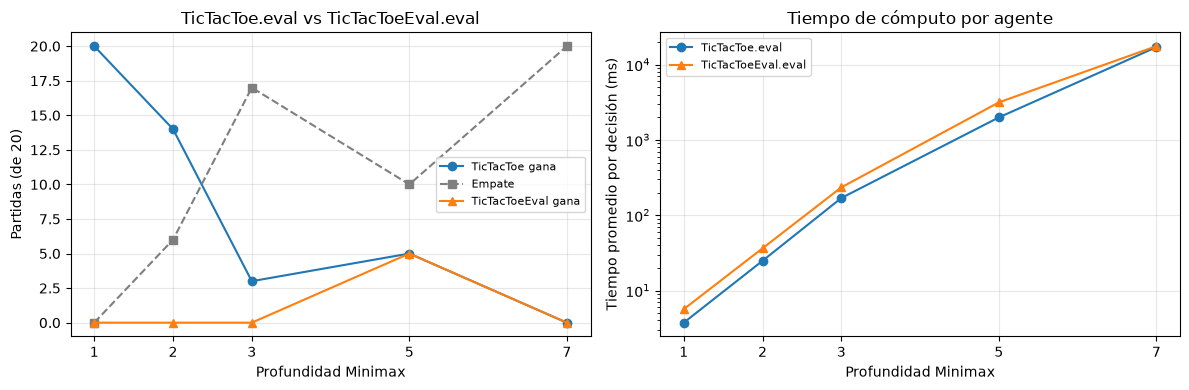

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df.depth, df.W_TicTacToe,     marker='o', color='tab:blue',   label='TicTacToe gana')
axes[0].plot(df.depth, df.D,                marker='s', color='tab:gray',   label='Empate',       linestyle='--')
axes[0].plot(df.depth, df.W_TicTacToeEval, marker='^', color='tab:orange', label='TicTacToeEval gana')
axes[0].set_xlabel('Profundidad Minimax')
axes[0].set_ylabel(f'Partidas (de {N})')
axes[0].set_title('TicTacToe.eval vs TicTacToeEval.eval')
axes[0].set_xticks(depths)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(df.depth, df.avg_ms_TicTacToe,     marker='o', color='tab:blue',   label='TicTacToe.eval')
axes[1].plot(df.depth, df.avg_ms_TicTacToeEval, marker='^', color='tab:orange', label='TicTacToeEval.eval')
axes[1].set_xlabel('Profundidad Minimax')
axes[1].set_ylabel('Tiempo promedio por decisión (ms)')
axes[1].set_title('Tiempo de cómputo por agente')
axes[1].set_xticks(depths)
axes[1].set_yscale('log')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'eval_benchmark.png')
plt.show()

## Conclusiones

En este benchmark, TicTacToe.eval obtiene mejores resultados a baja profundidad, especialmente en depth 1 y 2. A medida que aumenta la profundidad, ambos agentes tienden al empate. En depth 7, ambos empatan todas las partidas. En tiempo de cómputo, ambas funciones escalan de forma similar, aunque TicTacToeEval.eval es ligeramente más costosa por decisión.